In [1]:
!git clone https://github.com/beckhamtoh/char-llm-assignment.git
%cd char-llm-assignment

Cloning into 'char-llm-assignment'...
remote: Enumerating objects: 197, done.
remote: Total 197 (delta 0), reused 0 (delta 0), pack-reused 197 (from 1)
Receiving objects: 100% (197/197), 33.01 MiB | 13.82 MiB/s, done.
Resolving deltas: 100% (95/95), done.
/kaggle/working/char-llm-assignment


In [2]:
# Enable autoreload of local Python modules (e.g., models)
# %load_ext autoreload
# %autoreload 2

# manual reload for local modules
import importlib

In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import numpy as np
import jax
import jax.numpy as jnp
import optax
import time
import pandas as pd
import matplotlib.pyplot as plt
import json

# local imports
import models.models as models
import util.generation as generation


In [4]:
# initialize the jax random key
key = jax.random.key(0)

# Load data

In [5]:
# load the ./data/text8_train.txt and ./data/text8_test.txt files
with open("./data/text8_train.txt", "r") as f:
    train_text = f.read()
with open("./data/text8_test.txt", "r") as f:
    test_text = f.read()

# print the length of the training text and test text
print(f"Length of training text: {len(train_text):_} characters")
print(f"Length of test text: {len(test_text):_} characters")

Length of training text: 90_000_000 characters
Length of test text: 5_000_000 characters


In [6]:
# Build vocabulary (lowercase + space + a few punctuations)
char_set = list("abcdefghijklmnopqrstuvwxyz ")
char_to_int = {ch:i for i,ch in enumerate(char_set)}
int_to_char = {i:ch for ch,i in char_to_int.items()}

def encode(s):
    """Encode string to array of integers"""
    ids = [char_to_int[c] for c in s]
    return np.array(ids, dtype=np.uint8)  # use np.uint8 to save space

In [7]:
# encode the text
train_text_int = encode(train_text)
test_text_int = encode(test_text)

In [8]:
# sanity check: display a few random characters from the training text
T = 128
for _ in range(5):
    # choose random position in text
    N = np.random.randint(low=0, high=len(train_text)-T)
    print(train_text[N:N+T])
    print()

two zero zero five four terrorist bombings occurring exactly two weeks after the similar july seven bombings target london s pub

basic iso iec one zero two seven nine one nine nine one information technology programming languages full basic ansi iso iec add

six five years and over zero eight three male s female total population zero nine four male s female two zero zero five est infa

 vanishing sets of collections of polynomials meaning the set of all points that simultaneously satisfy one or more polynomial e

deceased during a funeral ceremony contemporary western influence however has meant that dark colored or black attire is now oft



# Create a basic Transformer model

In [9]:
def create_train_state(rng, vocab_size=27, d_model=64, n_layers=6, n_heads=8, max_len=128):
    # create a basic Transformer model
    model = models.DecoderOnlyTransformer(vocab_size, d_model, n_layers, n_heads, max_len)
    # create a dummy input for initialization
    dummy = jnp.zeros((1, min(16, max_len)), dtype=jnp.int32)
    # pass the dummy input to the model to initialize the parameters
    params = model.init({"params": rng}, dummy)["params"]
    return model, params

# Helper Functions

In [10]:
# Helper function to count parameters
def count_params(params):
    return sum(x.size for x in jax.tree_util.tree_leaves(params))

# Loss function
@jax.jit
def loss_and_metrics(logits, targets):
    """Compute cross-entropy loss and accuracy.
    Assumes targets contains only valid integer class ids in [0, V-1] (no -1 ignore tokens).
    Args:
        logits: (B, T, V) float array of unnormalized scores.
        targets: (B, T) integer array with ground-truth class ids.
    Returns:
        loss: scalar average cross-entropy over all positions.
        metrics: dict with keys "loss" and "acc" (both scalars).
    """
    # Flatten batch/time dims so optax works on shape (N, V) and (N,)
    vocab = logits.shape[-1]
    flat_logits = logits.reshape(-1, vocab)
    flat_targets = targets.reshape(-1)
    # Per-position cross-entropy, then mean over all positions
    per_pos = optax.softmax_cross_entropy_with_integer_labels(flat_logits, flat_targets)
    loss = per_pos.mean()
    # prediction over all positions
    preds = jnp.argmax(logits, axis=-1)  # (B, T)
    # compute accuracy over only the last position
    is_match = preds == targets
    # Accuracy over all positions
    acc_all = jnp.mean(is_match.astype(jnp.float32))
    # Accuracy over only last position
    acc_last = jnp.mean(is_match.astype(jnp.float32)[:, -1])
    return loss, {"loss": loss, "acc": acc_all, "acc_last": acc_last}


# Batch creation function
def get_batch(text_int, B, T):
    """Create a random batch of data from text_int.
    Args:
        text_int: 1D array of token ids.
        B: batch size (number of sequences).
        T: sequence length (number of tokens per sequence).
    Returns:
        x: (B, T) int array input tokens.
        y: (B, T) int array target tokens.
    """
    # choose random starting indices for each sequence in the batch
    ix = np.random.randint(0, len(text_int) - T, size=B)
    # inputs are text from i to i+T
    x = np.stack([text_int[i:i+T] for i in ix])
    # targets are text from i+1 to i+T+1
    y = np.stack([text_int[i+1:i+T+1] for i in ix])
    return jnp.array(x, dtype=jnp.int32), jnp.array(y, dtype=jnp.int32)

# Hyperparameter Search Framework


# Experiment Configuration

In [11]:
# STAGE 1: Quick exploration (120 seconds each)
# Goal: Identify which regions of hyperparameter space are promising
stage1_configs = [
    {"d_model": 128, "n_layers": 2, "n_heads": 2, "name": "s1_tiny", "time_budget": 120},
    {"d_model": 128, "n_layers": 4, "n_heads": 4, "name": "s1_small_deep", "time_budget": 120},
    {"d_model": 256, "n_layers": 2, "n_heads": 4, "name": "s1_medium_shallow", "time_budget": 120},
    {"d_model": 256, "n_layers": 4, "n_heads": 4, "name": "s1_medium_medium", "time_budget": 120},
    {"d_model": 512, "n_layers": 2, "n_heads": 8, "name": "s1_large_shallow", "time_budget": 120},
    {"d_model": 512, "n_layers": 4, "n_heads": 8, "name": "s1_large_medium", "time_budget": 120},
]

# STAGE 2: Ablation studies (120 seconds each)
# Goal: Understand impact of each hyperparameter while keeping others constant
stage2_configs = [
    # Ablation 1: Varying depth (d_model=256, n_heads=4, head_dim=64)
    {"d_model": 256, "n_layers": 1, "n_heads": 4, "name": "s2_depth_1L", "time_budget": 120, "group": "depth"},
    {"d_model": 256, "n_layers": 2, "n_heads": 4, "name": "s2_depth_2L", "time_budget": 120, "group": "depth"},
    {"d_model": 256, "n_layers": 4, "n_heads": 4, "name": "s2_depth_4L", "time_budget": 120, "group": "depth"},
    {"d_model": 256, "n_layers": 6, "n_heads": 4, "name": "s2_depth_6L", "time_budget": 120, "group": "depth"},
    
    # Ablation 2: Varying hidden size (n_layers=4, head_dim≈64)
    {"d_model": 128, "n_layers": 4, "n_heads": 2, "name": "s2_width_128", "time_budget": 120, "group": "width"},
    {"d_model": 256, "n_layers": 4, "n_heads": 4, "name": "s2_width_256", "time_budget": 120, "group": "width"},
    {"d_model": 512, "n_layers": 4, "n_heads": 8, "name": "s2_width_512", "time_budget": 120, "group": "width"},
    
    # Ablation 3: Varying head_dim (d_model=256, n_layers=4)
    {"d_model": 256, "n_layers": 4, "n_heads": 16, "name": "s2_head16", "time_budget": 120, "group": "head_dim"},
    {"d_model": 256, "n_layers": 4, "n_heads": 8, "name": "s2_head32", "time_budget": 120, "group": "head_dim"},
    {"d_model": 256, "n_layers": 4, "n_heads": 4, "name": "s2_head64", "time_budget": 120, "group": "head_dim"},
    {"d_model": 256, "n_layers": 4, "n_heads": 2, "name": "s2_head128", "time_budget": 120, "group": "head_dim"},
]

# STAGE 3: Interaction exploration (120 seconds each)
# Goal: Test how hyperparameters interact (wide vs deep, etc.)
stage3_configs = [
    # Wide & shallow vs narrow & deep trade-offs
    {"d_model": 512, "n_layers": 2, "n_heads": 8, "name": "s3_wide_shallow", "time_budget": 120, "group": "tradeoff"},
    {"d_model": 256, "n_layers": 6, "n_heads": 4, "name": "s3_narrow_deep", "time_budget": 120, "group": "tradeoff"},
    {"d_model": 384, "n_layers": 4, "n_heads": 6, "name": "s3_balanced", "time_budget": 120, "group": "tradeoff"},
    
    # Test with head_dim=32 (character-level might prefer smaller)
    {"d_model": 256, "n_layers": 4, "n_heads": 8, "name": "s3_head32_medium", "time_budget": 120, "group": "char_level"},
    {"d_model": 512, "n_layers": 6, "n_heads": 16, "name": "s3_head32_large", "time_budget": 120, "group": "char_level"},
]

# STAGE 4: Best candidates (will fill in after seeing results)
# Train top 2-3 models to convergence (30 minutes each)
stage4_configs = [
    {"d_model": 128, "n_layers": 4, "n_heads": 4, "name": "s4_small_deep", "time_budget": 1800, "group": "final"},
    {"d_model": 256, "n_layers": 4, "n_heads": 8, "name": "s4_head32_medium", "time_budget": 1800, "group": "final"},
    {"d_model": 128, "n_layers": 4, "n_heads": 2, "name": "s4_width_128", "time_budget": 1800, "group": "final"},
    {"d_model": 512, "n_layers": 4, "n_heads": 8, "name": "s4_width_128", "time_budget": 1800, "group": "final"},
    {"d_model": 256, "n_layers": 4, "n_heads": 4, "name": "s4_width_128", "time_budget": 1800, "group": "final"},
]

In [12]:
configurations = stage1_configs + stage2_configs + stage3_configs + stage4_configs

# Add computed fields
for config in configurations:
    config['head_dim'] = config['d_model'] // config['n_heads']
    config['group'] = config.get('group', 'exploration')

print(f"\n{'='*80}")
print(f"EXPERIMENTAL SETUP")
print(f"{'='*80}")
print(f"Total configurations to test: {len(configurations)}")
print(f"\nConfiguration summary:")
print(pd.DataFrame(configurations)[['name', 'd_model', 'n_layers', 'n_heads', 'head_dim', 'time_budget', 'group']])
print(f"{'='*80}\n")


EXPERIMENTAL SETUP
Total configurations to test: 22

Configuration summary:
                 name  d_model  n_layers  n_heads  head_dim  time_budget  \
0             s1_tiny      128         2        2        64          120   
1       s1_small_deep      128         4        4        32          120   
2   s1_medium_shallow      256         2        4        64          120   
3    s1_medium_medium      256         4        4        64          120   
4    s1_large_shallow      512         2        8        64          120   
5     s1_large_medium      512         4        8        64          120   
6         s2_depth_1L      256         1        4        64          120   
7         s2_depth_2L      256         2        4        64          120   
8         s2_depth_4L      256         4        4        64          120   
9         s2_depth_6L      256         6        4        64          120   
10       s2_width_128      128         4        2        64          120   
11       s2

# Training Function

In [13]:
# Training Function
def train_model_with_tracking(config, train_text_int, test_text_int, vocab_size, max_len, learning_rate):
    """
    Train a single model configuration for a fixed time budget and track performance over time.
    
    Returns:
        result: dict with final metrics and training history
        params: trained model parameters
    """
    time_budget = config['time_budget']
    
    print(f"\n{'='*80}")
    print(f"Training: {config['name']}")
    print(f"  Architecture: d_model={config['d_model']}, n_layers={config['n_layers']}, "
          f"n_heads={config['n_heads']}, head_dim={config['head_dim']}")
    print(f"  Time Budget: {time_budget} seconds")
    print(f"{'='*80}")
    
    # Create model
    model, params = create_train_state(
        key, 
        vocab_size=vocab_size,
        d_model=config['d_model'],
        n_layers=config['n_layers'],
        n_heads=config['n_heads'],
        max_len=max_len
    )
    
    n_params = count_params(params)
    print(f"  Parameters: {n_params:,}")
    
    # Setup optimizer
    tx = optax.adam(learning_rate=learning_rate)
    opt_state = tx.init(params)
    
    # Define train_step INSIDE this function so it has access to 'model'
    def train_step_local(params, opt_state, x, y):
        """Single optimization step."""
        def loss_fn(params):
            logits = model.apply({"params": params}, x)
            loss, metrics = loss_and_metrics(logits, y)
            return loss, metrics
        
        # compute gradients
        (loss, metrics), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)
        # optax update
        updates, new_opt_state = tx.update(grads, opt_state, params)
        new_params = optax.apply_updates(params, updates)
        return new_params, new_opt_state, metrics
    
    # JIT compile the train step
    train_step_jitted = jax.jit(train_step_local)
    
    # Training configuration
    B, T = 128, 32
    B_test, T_test = 1024, 32
    
    # Tracking
    time_start = time.time()
    checkpoint_interval = max(1, time_budget // 20)  # 20 checkpoints throughout training
    last_checkpoint_time = 0
    
    history = {
        'iteration': [],
        'time_elapsed': [],
        'train_loss': [],
        'test_loss': [],
        'test_acc': [],
        'test_acc_last': []
    }
    
    # Training loop - run until time budget is exhausted
    it = 0
    while True:
        # Training step
        batch = get_batch(train_text_int, B, T)
        input, target = batch[0], batch[1]
        params, opt_state, metrics = train_step_jitted(params, opt_state, input, target)
        
        time_elapsed = time.time() - time_start
        
        # Check if time budget is exhausted
        if time_elapsed >= time_budget:
            # Final evaluation before breaking
            test_batch = get_batch(test_text_int, B_test, T_test)
            test_input, test_target = test_batch[0], test_batch[1]
            test_logits = model.apply({"params": params}, test_input)
            test_loss, test_metrics = loss_and_metrics(test_logits, test_target)
            
            # Record final checkpoint
            history['iteration'].append(it)
            history['time_elapsed'].append(time_elapsed)
            history['train_loss'].append(float(metrics['loss']))
            history['test_loss'].append(float(test_loss))
            history['test_acc'].append(float(test_metrics['acc']))
            history['test_acc_last'].append(float(test_metrics['acc_last']))
            
            print(f"  iter {it:>7,} | time {time_elapsed:>7.1f}s | "
                  f"train_loss {metrics['loss']:.4f} | test_loss {test_loss:.4f} | "
                  f"test_acc {100*test_metrics['acc']:.2f}% | "
                  f"test_acc_last {100*test_metrics['acc_last']:.2f}%")
            break
        
        # Periodic evaluation based on time
        if time_elapsed - last_checkpoint_time >= checkpoint_interval:
            last_checkpoint_time = time_elapsed
            
            # Test evaluation
            test_batch = get_batch(test_text_int, B_test, T_test)
            test_input, test_target = test_batch[0], test_batch[1]
            test_logits = model.apply({"params": params}, test_input)
            test_loss, test_metrics = loss_and_metrics(test_logits, test_target)
            
            # Record history
            history['iteration'].append(it)
            history['time_elapsed'].append(time_elapsed)
            history['train_loss'].append(float(metrics['loss']))
            history['test_loss'].append(float(test_loss))
            history['test_acc'].append(float(test_metrics['acc']))
            history['test_acc_last'].append(float(test_metrics['acc_last']))
            
            # Print progress
            print(f"  iter {it:>7,} | time {time_elapsed:>7.1f}s | "
                  f"train_loss {metrics['loss']:.4f} | test_loss {test_loss:.4f} | "
                  f"test_acc {100*test_metrics['acc']:.2f}% | "
                  f"test_acc_last {100*test_metrics['acc_last']:.2f}%")
        
        it += 1
    
    total_time = time.time() - time_start
    total_iters = it
    
    # Final evaluation (one more time on test set)
    test_batch = get_batch(test_text_int, B_test, T_test)
    test_input, test_target = test_batch[0], test_batch[1]
    test_logits = model.apply({"params": params}, test_input)
    final_test_loss, final_test_metrics = loss_and_metrics(test_logits, test_target)
    
    # Compile results
    result = {
        'name': config['name'],
        'd_model': config['d_model'],
        'n_layers': config['n_layers'],
        'n_heads': config['n_heads'],
        'head_dim': config['head_dim'],
        'n_params': n_params,
        'time_budget': time_budget,
        'total_iters': total_iters,
        'total_time': total_time,
        'time_per_iter': total_time / total_iters if total_iters > 0 else 0,
        'iters_per_sec': total_iters / total_time if total_time > 0 else 0,
        'final_train_loss': float(metrics['loss']),
        'final_test_loss': float(final_test_loss),
        'final_test_acc': float(final_test_metrics['acc']),
        'final_test_acc_last': float(final_test_metrics['acc_last']),
        'group': config['group'],
        'history': history
    }
    
    print(f"\n{'='*40}")
    print(f"  FINAL RESULTS:")
    print(f"  Test Loss: {final_test_loss:.4f}")
    print(f"  Test Accuracy (all positions): {100*final_test_metrics['acc']:.2f}%")
    print(f"  Test Accuracy (last char): {100*final_test_metrics['acc_last']:.2f}%")
    print(f"  Training Time: {total_time:.1f}s ({total_time/60:.1f}m)")
    print(f"  Total Iterations: {total_iters:,}")
    print(f"  Speed: {total_iters/total_time:.1f} iter/s")
    print(f"{'='*40}\n")
    
    return result, params

# Training

In [14]:
# Global settings
vocab_size = len(char_set)
max_len = 128
learning_rate = 0.001

results = []
trained_models = {}

print(f"\n{'#'*80}")
print(f"STARTING HYPERPARAMETER SEARCH")
print(f"{'#'*80}\n")

experiment_start_time = time.time()

for config_idx, config in enumerate(configurations):
    print(f"\n{'#'*80}")
    print(f"Configuration {config_idx + 1}/{len(configurations)}")
    print(f"{'#'*80}")
    
    # Train model
    result, params = train_model_with_tracking(
        config, 
        train_text_int, 
        test_text_int, 
        vocab_size, 
        max_len, 
        learning_rate
    )
    
    results.append(result)
    trained_models[config['name']] = params
    
    # Save intermediate results (in case of crash)
    temp_df = pd.DataFrame(results)
    temp_df.to_csv('experiment_results_temp.csv', index=False)

total_experiment_time = time.time() - experiment_start_time

print(f"\n{'#'*80}")
print(f"ALL EXPERIMENTS COMPLETE")
print(f"Total time: {total_experiment_time/60:.1f} minutes ({total_experiment_time/3600:.2f} hours)")
print(f"{'#'*80}\n")



################################################################################
STARTING HYPERPARAMETER SEARCH
################################################################################


################################################################################
Configuration 1/22
################################################################################

Training: s1_tiny
  Architecture: d_model=128, n_layers=2, n_heads=2, head_dim=64
  Time Budget: 120 seconds
  Parameters: 419,072
  iter     417 | time     6.0s | train_loss 1.9144 | test_loss 1.8967 | test_acc 42.17% | test_acc_last 42.87%
  iter   1,064 | time    12.0s | train_loss 1.6457 | test_loss 1.6996 | test_acc 48.25% | test_acc_last 47.36%
  iter   2,161 | time    18.0s | train_loss 1.5485 | test_loss 1.5834 | test_acc 50.93% | test_acc_last 52.93%
  iter   3,244 | time    24.0s | train_loss 1.4864 | test_loss 1.5392 | test_acc 52.91% | test_acc_last 55.47%
  iter   4,319 | time    30.0s | train_loss 1.5

# Visualizations

In [16]:
print(f"\n{'='*80}")
print(f"SUMMARY OF ALL CONFIGURATIONS")
print(f"{'='*80}\n")

summary_cols = ['name', 'd_model', 'n_layers', 'n_heads', 'head_dim', 'n_params', 
                'final_test_acc_last', 'final_test_loss', 'total_iters', 'time_budget', 'group']
print(results_df[summary_cols].to_string(index=False))

# Rank by test accuracy
print(f"\n{'='*80}")
print(f"TOP 10 MODELS BY TEST ACCURACY (LAST CHARACTER)")
print(f"{'='*80}\n")

results_df_sorted = results_df.sort_values('final_test_acc_last', ascending=False)
top10_cols = ['name', 'n_params', 'final_test_acc_last', 'final_test_loss', 'total_iters', 'time_budget']
print(results_df_sorted[top10_cols].head(10).to_string(index=False))

# Best in each group
print(f"\n{'='*80}")
print(f"BEST MODEL IN EACH EXPERIMENTAL GROUP")
print(f"{'='*80}\n")

for group in results_df['group'].unique():
    group_df = results_df[results_df['group'] == group]
    best_in_group = group_df.sort_values('final_test_acc_last', ascending=False).iloc[0]
    print(f"{group:15s} : {best_in_group['name']:20s} "
          f"acc={100*best_in_group['final_test_acc_last']:.2f}% "
          f"params={best_in_group['n_params']:,} "
          f"iters={best_in_group['total_iters']:,}")


SUMMARY OF ALL CONFIGURATIONS

             name  d_model  n_layers  n_heads  head_dim  n_params  final_test_acc_last  final_test_loss  total_iters  time_budget       group
          s1_tiny      128         2        2        64    419072             0.572266         1.426504        19175          120 exploration
    s1_small_deep      128         4        4        32    814592             0.601562         1.388844         9238          120 exploration
s1_medium_shallow      256         2        4        64   1624576             0.572266         1.443036         5938          120 exploration
 s1_medium_medium      256         4        4        64   3202048             0.558594         1.448581         3058          120 exploration
 s1_large_shallow      512         2        8        64   6394880             0.542969         1.547305         1731          120 exploration
  s1_large_medium      512         4        8        64  12695552             0.490234         1.674501          896


GENERATING PLOTS...

✓ Main plot saved to 'hyperparameter_search_results.png'


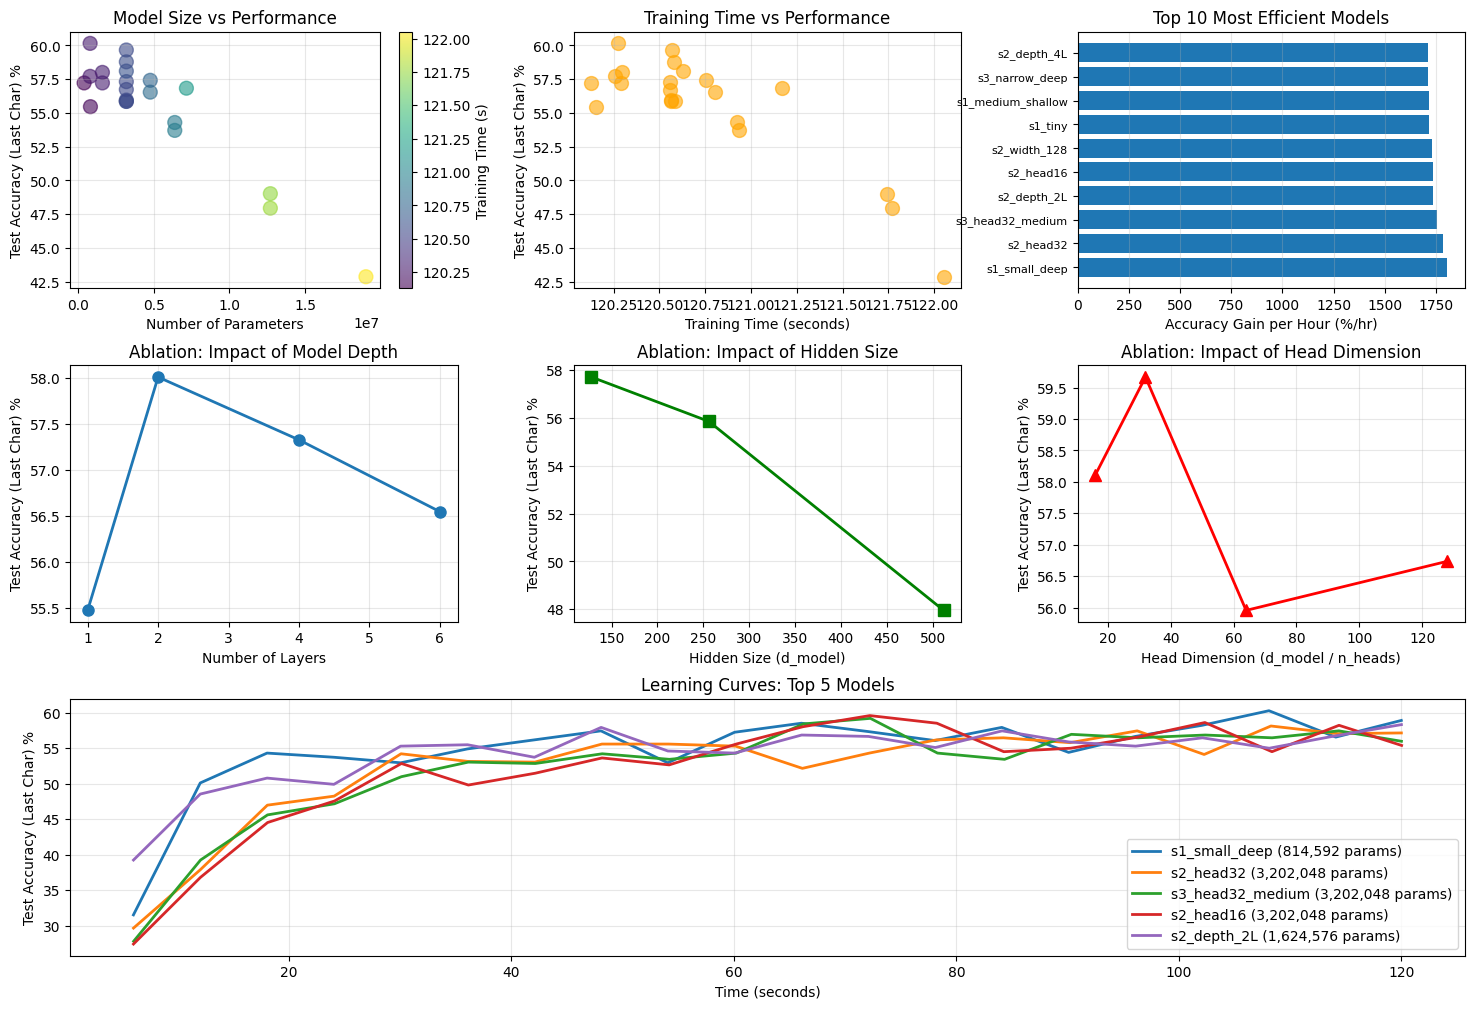

✓ Complexity plot saved to 'model_complexity_vs_cost.png'


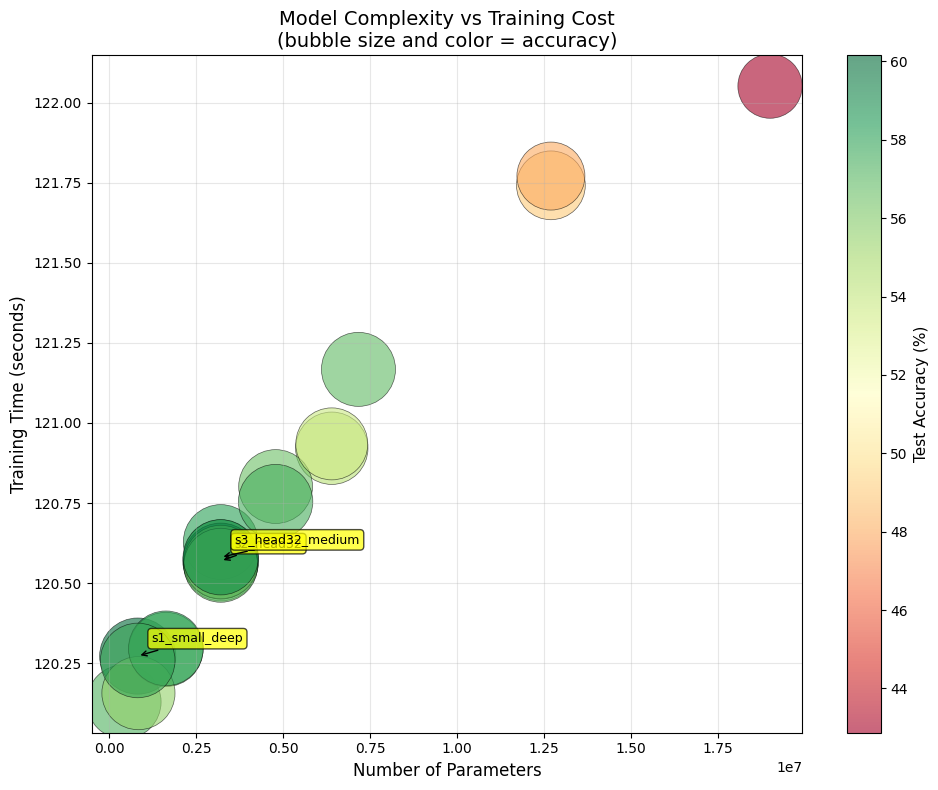

In [17]:
print(f"\n{'='*80}")
print(f"GENERATING PLOTS...")
print(f"{'='*80}\n")

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Plot 1: Model size vs accuracy
ax1 = fig.add_subplot(gs[0, 0])
scatter = ax1.scatter(results_df['n_params'], results_df['final_test_acc_last'] * 100, 
                      c=results_df['total_time'], s=100, alpha=0.6, cmap='viridis')
ax1.set_xlabel('Number of Parameters')
ax1.set_ylabel('Test Accuracy (Last Char) %')
ax1.set_title('Model Size vs Performance')
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax1, label='Training Time (s)')

# Plot 2: Training time vs accuracy
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(results_df['total_time'], results_df['final_test_acc_last'] * 100, 
            s=100, alpha=0.6, color='orange')
ax2.set_xlabel('Training Time (seconds)')
ax2.set_ylabel('Test Accuracy (Last Char) %')
ax2.set_title('Training Time vs Performance')
ax2.grid(True, alpha=0.3)

# Plot 3: Efficiency (accuracy per hour)
ax3 = fig.add_subplot(gs[0, 2])
results_df['acc_per_hour'] = results_df['final_test_acc_last'] * 100 / (results_df['total_time'] / 3600)
top_efficient = results_df.nlargest(10, 'acc_per_hour')
ax3.barh(range(len(top_efficient)), top_efficient['acc_per_hour'])
ax3.set_yticks(range(len(top_efficient)))
ax3.set_yticklabels(top_efficient['name'], fontsize=8)
ax3.set_xlabel('Accuracy Gain per Hour (%/hr)')
ax3.set_title('Top 10 Most Efficient Models')
ax3.grid(True, alpha=0.3, axis='x')

# Plot 4: Impact of depth (ablation group)
ax4 = fig.add_subplot(gs[1, 0])
depth_results = results_df[results_df['group'] == 'depth'].sort_values('n_layers')
if len(depth_results) > 0:
    ax4.plot(depth_results['n_layers'], depth_results['final_test_acc_last'] * 100, 
             marker='o', linewidth=2, markersize=8)
    ax4.set_xlabel('Number of Layers')
    ax4.set_ylabel('Test Accuracy (Last Char) %')
    ax4.set_title('Ablation: Impact of Model Depth')
    ax4.grid(True, alpha=0.3)

# Plot 5: Impact of width (ablation group)
ax5 = fig.add_subplot(gs[1, 1])
width_results = results_df[results_df['group'] == 'width'].sort_values('d_model')
if len(width_results) > 0:
    ax5.plot(width_results['d_model'], width_results['final_test_acc_last'] * 100, 
             marker='s', linewidth=2, markersize=8, color='green')
    ax5.set_xlabel('Hidden Size (d_model)')
    ax5.set_ylabel('Test Accuracy (Last Char) %')
    ax5.set_title('Ablation: Impact of Hidden Size')
    ax5.grid(True, alpha=0.3)

# Plot 6: Impact of head_dim (ablation group)
ax6 = fig.add_subplot(gs[1, 2])
head_results = results_df[results_df['group'] == 'head_dim'].sort_values('head_dim')
if len(head_results) > 0:
    ax6.plot(head_results['head_dim'], head_results['final_test_acc_last'] * 100, 
             marker='^', linewidth=2, markersize=8, color='red')
    ax6.set_xlabel('Head Dimension (d_model / n_heads)')
    ax6.set_ylabel('Test Accuracy (Last Char) %')
    ax6.set_title('Ablation: Impact of Head Dimension')
    ax6.grid(True, alpha=0.3)

# Plot 7: Training curves (top 5 models)
ax7 = fig.add_subplot(gs[2, :])
top5 = results_df.nlargest(5, 'final_test_acc_last')
for idx, row in top5.iterrows():
    history = row['history']
    ax7.plot(history['time_elapsed'], 
             [x*100 for x in history['test_acc_last']], 
             label=f"{row['name']} ({row['n_params']:,} params)", 
             linewidth=2)
ax7.set_xlabel('Time (seconds)')
ax7.set_ylabel('Test Accuracy (Last Char) %')
ax7.set_title('Learning Curves: Top 5 Models')
ax7.legend(loc='lower right')
ax7.grid(True, alpha=0.3)

plt.savefig('hyperparameter_search_results.png', dpi=300, bbox_inches='tight')
print(f"✓ Main plot saved to 'hyperparameter_search_results.png'")
plt.show()

# Additional plot: Params vs Time vs Accuracy (3D-like)
fig2, ax = plt.subplots(1, 1, figsize=(10, 8))
scatter = ax.scatter(results_df['n_params'], 
                     results_df['total_time'], 
                     s=results_df['final_test_acc_last']*5000,  # size = accuracy
                     c=results_df['final_test_acc_last']*100,
                     cmap='RdYlGn', 
                     alpha=0.6,
                     edgecolors='black',
                     linewidth=0.5)
ax.set_xlabel('Number of Parameters', fontsize=12)
ax.set_ylabel('Training Time (seconds)', fontsize=12)
ax.set_title('Model Complexity vs Training Cost\n(bubble size and color = accuracy)', fontsize=14)
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Test Accuracy (%)', fontsize=11)

# Annotate best models
top3 = results_df.nlargest(3, 'final_test_acc_last')
for idx, row in top3.iterrows():
    ax.annotate(row['name'], 
                (row['n_params'], row['total_time']),
                xytext=(10, 10), 
                textcoords='offset points',
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.tight_layout()
plt.savefig('model_complexity_vs_cost.png', dpi=300, bbox_inches='tight')
print(f"✓ Complexity plot saved to 'model_complexity_vs_cost.png'")
plt.show()